# RANDOM FOREST

### Random Forest Defination
    In machine learning, a Random Forest is an ensemble learning algorithm that builds and combines multiple decision trees to improve prediction accuracy and reduce overfitting.
### Key Points:

    Type: Supervised learning (used for both classification and regression).
    
### How it works:

> * Creates many decision trees, each trained on a random subset of the training data (bootstrapping).
> * At each split in a tree, it considers a random subset of features instead of all features.
> * For classification, it uses majority voting across trees; for regression, it takes the average of predictions.


### Advantages:

> * Handles large datasets and high-dimensional features well.
> * Reduces overfitting compared to a single decision tree.
> * Works well with missing data and maintains accuracy for unbalanced datasets.


### Limitations:

> * Can be slower to predict with very large forests.
> * Less interpretable than a single decision tree.


## PROBLEM STATEMENT

### 📌 Problem Statement

    * Forests are vital ecosystems that require careful monitoring and management. The *Covtype* dataset provides cartographic variables such as elevation, slope, soil type, and climate features, which can be used to classify different forest cover types. The challenge is to build a machine learning model that can accurately predict the forest cover type (seven possible classes) based on these environmental attributes.  

    * This is a **multi-class classification problem**, where the objective is to develop a predictive model using a **Decision Tree algorithm**. The model should not only achieve high accuracy but also provide interpretable insights into which features (e.g., elevation, soil type, wilderness area) most influence forest cover classification. Such predictions can support ecological research, land management, and conservation planning.

## DATA COLLECTION

## 📊 Data Collection (Forest Cover Classification):

1. **Source of Data**  
    - The dataset from kaggle websites. Link: https://www.kaggle.com/datasets/uciml/forest-cover-type-dataset
    - The dataset used in this project is the **Forest Cover Type dataset (Covtype)**, originally from the **UCI Machine Learning Repository**.  
    - It contains cartographic variables derived from US Geological Survey data. 


2. **Dataset Description**  
   - **Instances:** ~581,000 records  
   - **Features:** 54 attributes (both continuous and categorical)  
   - **Target Variable:** `Cover_Type` (integer values 1–7, representing seven forest cover types)  
   - **Feature Categories:**  
     - Elevation, Aspect, Slope  
     - Horizontal & Vertical distances to hydrology  
     - Hillshade indices (morning, noon, afternoon)  
     - Soil type (categorical, 40 binary indicators)  
     - Wilderness area (categorical, 4 binary indicators)  

3. **Nature of Data**  
   - Structured **tabular dataset** (rows = forest plots, columns = features).  
   - Each row represents one forest plot with environmental attributes and its corresponding forest cover type.  

4. **Purpose of Collection**  
   - To classify forest cover types based on environmental and soil features.  
   - Supports ecological monitoring, land management, and predictive modeling.  

5. **Storage & Access**  
   - Stored as a `.csv` file (`covtype.csv`).  
   - Loaded into Python using `pandas.read_csv("covtype.csv")`.  
   - Preprocessed before feeding into the Decision Tree algorithm.  


## DOMAIN ANALYSIS

## 🌐 Domain Analysis (Forest Cover Classification)

### 1. **Context**
Forests are complex ecosystems influenced by terrain, soil, and climate. Predicting forest cover type is crucial for ecological monitoring, wildfire prevention, and sustainable land management. The Covtype dataset provides cartographic variables (elevation, slope, soil type, wilderness area, hydrology distances, hillshade indices) that can be used to classify forest cover types into seven categories.

---

### 2. **Challenges**
- **High Dimensionality:** 54 features, including categorical indicators for soil and wilderness areas.  
- **Class Imbalance:** Some forest types are more frequent than others, leading to skewed predictions.  
- **Non-linear Relationships:** Environmental variables interact in complex ways that simple linear models may fail to capture.  
- **Overfitting Risk:** Decision Trees can easily overfit if not properly tuned (e.g., depth control).  

---

### 3. **Analytical Needs**
- Feature engineering to handle categorical variables effectively.  
- Dimensionality reduction or feature importance analysis to identify key predictors.  
- Robust evaluation metrics beyond accuracy (precision, recall, F1-score).  
- Interpretability to understand which environmental factors drive classification.  

---

### 4. **Role of Decision Tree**
- Handles both numerical and categorical features without extensive preprocessing.  
- Provides interpretable rules for forest cover classification.  
- Captures non-linear interactions between terrain and soil variables.  
- Serves as a baseline model before moving to ensemble methods (Random Forest, Gradient Boosting).  

---

### 5. **Business & Research Impact**
- **Ecological Monitoring:** Helps researchers identify forest types based on terrain and soil data.  
- **Land Management:** Supports government agencies in planning conservation strategies.  
- **Wildfire Prevention:** Certain forest types are more prone to fire; classification aids risk assessment.  
- **Data-Driven Insights:** Elevation and soil type often emerge as dominant predictors, guiding resource allocation.  

## IMPORTING LIBRARIES

In [14]:
# Data handling
import pandas as pd        # For loading and manipulating CSV data
import numpy as np         # For numerical operations

# Visualization
import matplotlib.pyplot as plt   # For plotting graphs
import seaborn as sns             # For advanced visualizations

# Preprocessing
from sklearn.model_selection import train_test_split   # For splitting dataset
from sklearn.preprocessing import StandardScaler       # For feature scaling

# Model
from sklearn.ensemble import RandomForestClassifier    # Random Forest algorithm

# Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Utility
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

### 🔑 Explanation of Each Library
- **pandas** → For loading and handling the dataset (`covtype.csv`).  
- **numpy** → For numerical operations and array manipulations.  
- **matplotlib & seaborn** → For data visualization (feature distributions, correlations, confusion matrix plots).  
- **sklearn.model_selection** → Provides `train_test_split` to divide data into training and testing sets.  
- **from sklearn.ensemble import RandomForestClassifier ** → Core algorithm for building RANDOM FOREST  Tree model. 
- **sklearn.metrics** → Tools to evaluate model performance (accuracy, precision, recall, F1-score, confusion matrix).

## LOADING DATASET

In [2]:
import pandas as pd

# Step 1: Load dataset
df = pd.read_csv("covtype.csv")

# Step 2: Inspect dataset
print("Dataset Shape:\n", df.shape)   # Rows and columns
print(df.head()) # First 5 records
print(df.tail()) # last 5 records
print(df.info()) 

Dataset Shape:
 (581012, 55)
   Elevation  Aspect  Slope  Horizontal_Distance_To_Hydrology  \
0       2596      51      3                               258   
1       2590      56      2                               212   
2       2804     139      9                               268   
3       2785     155     18                               242   
4       2595      45      2                               153   

   Vertical_Distance_To_Hydrology  Horizontal_Distance_To_Roadways  \
0                               0                              510   
1                              -6                              390   
2                              65                             3180   
3                             118                             3090   
4                              -1                              391   

   Hillshade_9am  Hillshade_Noon  Hillshade_3pm  \
0            221             232            148   
1            220             235            151   
2     

### 📊 Explanation
- `df.shape` → Displays the number of rows and columns (expected ~581,000 rows and 55 columns).  
- `df.head()` → Shows the first few records for a quick preview.
- `df.tail()` → Shows the last few records for a quick preview. 
- `df.info()` → Provides details about column data types and missing values.  

## BASIC CHECKS

In [3]:
# Dataset shape
print("Shape of dataset:", df.shape)

# Column info
print("\nColumn Information:")
print(df.info())

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Duplicate records
print("\nDuplicate Records:", df.duplicated().sum())

# Target variable distribution
print("\nCover_Type Distribution:")
print(df['Cover_Type'].value_counts())

Shape of dataset: (581012, 55)

Column Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 581012 entries, 0 to 581011
Data columns (total 55 columns):
 #   Column                              Non-Null Count   Dtype
---  ------                              --------------   -----
 0   Elevation                           581012 non-null  int64
 1   Aspect                              581012 non-null  int64
 2   Slope                               581012 non-null  int64
 3   Horizontal_Distance_To_Hydrology    581012 non-null  int64
 4   Vertical_Distance_To_Hydrology      581012 non-null  int64
 5   Horizontal_Distance_To_Roadways     581012 non-null  int64
 6   Hillshade_9am                       581012 non-null  int64
 7   Hillshade_Noon                      581012 non-null  int64
 8   Hillshade_3pm                       581012 non-null  int64
 9   Horizontal_Distance_To_Fire_Points  581012 non-null  int64
 10  Wilderness_Area1                    581012 non-null  int64
 11  

### 📌 Explanation
- **Shape:** Confirms ~581,000 rows and 55 columns.  
- **Info:** Ensures all features are properly typed (int/float).  
- **Missing Values:** Covtype dataset typically has **no missing values**, but this check validates it.  
- **Duplicates:** Rare, but checking ensures data integrity.  
- **Distribution:** Reveals class imbalance (some forest types are more frequent than others).  

## Exploratory Data Analysis (EDA)

### 1. **Dataset Overview**

In [4]:
# Basic info
print(df.shape)        # (581012, 55)
print(df.info())       # datatypes of each column
print(df.describe())   # statistical summary

(581012, 55)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 581012 entries, 0 to 581011
Data columns (total 55 columns):
 #   Column                              Non-Null Count   Dtype
---  ------                              --------------   -----
 0   Elevation                           581012 non-null  int64
 1   Aspect                              581012 non-null  int64
 2   Slope                               581012 non-null  int64
 3   Horizontal_Distance_To_Hydrology    581012 non-null  int64
 4   Vertical_Distance_To_Hydrology      581012 non-null  int64
 5   Horizontal_Distance_To_Roadways     581012 non-null  int64
 6   Hillshade_9am                       581012 non-null  int64
 7   Hillshade_Noon                      581012 non-null  int64
 8   Hillshade_3pm                       581012 non-null  int64
 9   Horizontal_Distance_To_Fire_Points  581012 non-null  int64
 10  Wilderness_Area1                    581012 non-null  int64
 11  Wilderness_Area2                    581

- **Rows:** 581,012  
- **Columns:** 55 (54 features + 1 target)  
- **Target:** `Cover_Type` (7 forest categories)  
- **Observation:** No missing values, mix of continuous and binary features.

### 2. **Target Variable Distribution**

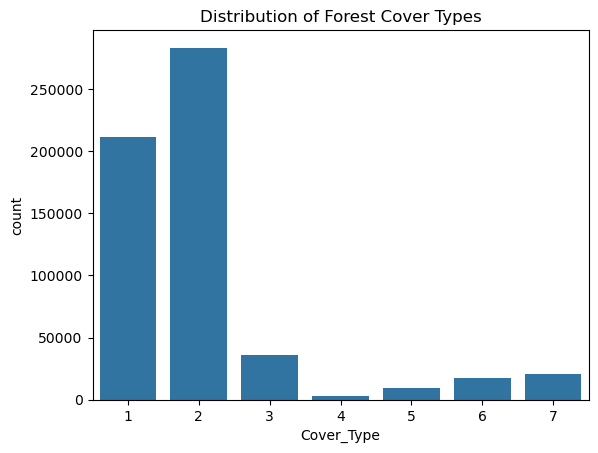

In [5]:
sns.countplot(x='Cover_Type', data=df)
plt.title("Distribution of Forest Cover Types")
plt.show();

- **Insight:** Class imbalance exists.  
  - Lodgepole Pine (Class 2) dominates (~48%).  
  - Aspen (Class 5) and Cottonwood/Willow (Class 4) are rare.  
- **Impact:** May require balancing techniques (SMOTE, class weights).

### 3. **Continuous Feature Analysis**

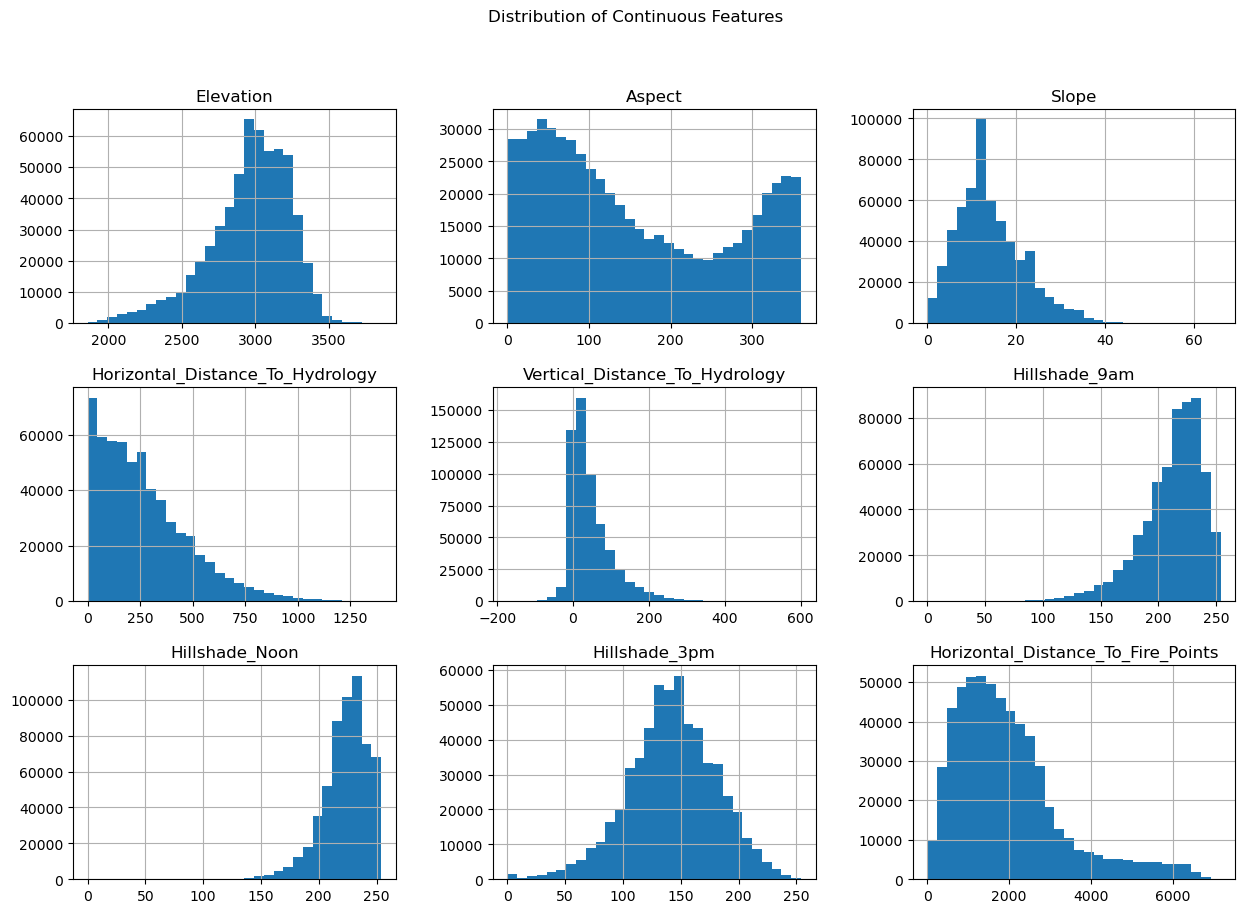

In [6]:
continuous_features = ['Elevation','Aspect','Slope',
                       'Horizontal_Distance_To_Hydrology',
                       'Vertical_Distance_To_Hydrology',
                       'Hillshade_9am','Hillshade_Noon','Hillshade_3pm',
                       'Horizontal_Distance_To_Fire_Points']

df[continuous_features].hist(bins=30, figsize=(15,10))
plt.suptitle("Distribution of Continuous Features")
plt.show();

- *Elevation:** Strongly influences forest type (higher elevation → Spruce/Fir).  
- **Slope & Aspect:** Show natural terrain variation.  
- **Hillshade values:** Capture sunlight exposure at different times of day.

### 4. **Categorical Feature Analysis**

# Wilderness Area (4 binary features)
wilderness_cols = [col for col in df.columns if 'Wilderness_Area' in col]
df[wilderness_cols].sum().plot(kind='bar')
plt.title("Wilderness Area Distribution")
plt.show();

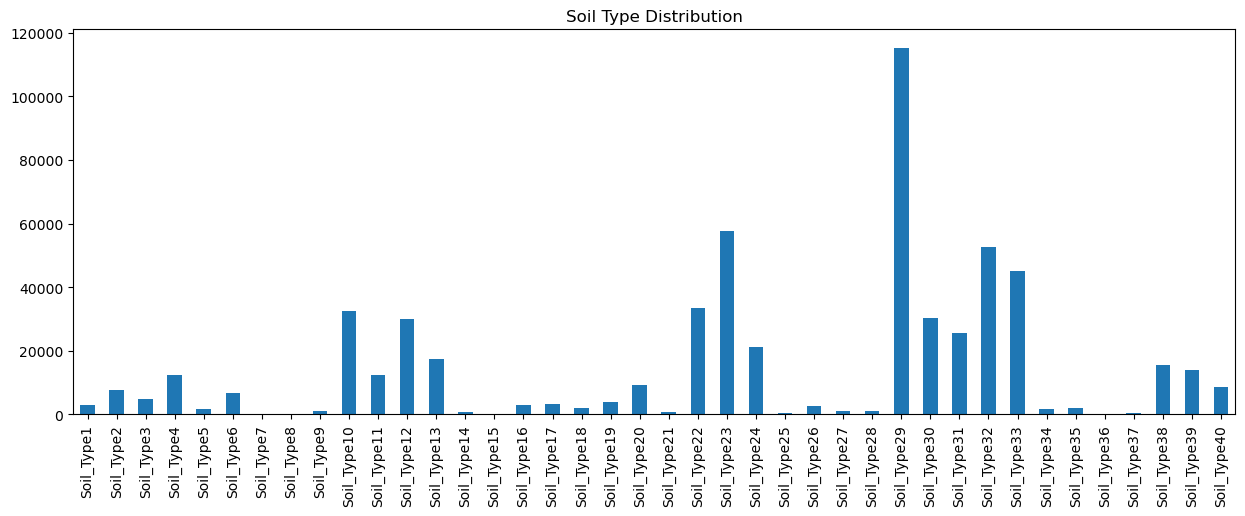

In [8]:
# Soil Type (40 binary features)
soil_cols = [col for col in df.columns if 'Soil_Type' in col]
df[soil_cols].sum().plot(kind='bar', figsize=(15,5))
plt.title("Soil Type Distribution")
plt.show();

- **Wilderness Areas:** Uneven distribution; some areas dominate.  
- **Soil Types:** Certain soil types occur far more frequently, influencing cover type.

### 5. **Correlation Analysis**

In [ ]:
corr = df[continuous_features].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Continuous Features")
plt.show();

- **Insight:**  
  - Elevation correlates with Vertical Distance to Hydrology.  
  - Hillshade features are moderately correlated.  
  - Most features are weakly correlated → good for Random Forest (handles uncorrelated features well).

### 6. **Feature Importance (Quick Check with Random Forest)**

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X = df.drop('Cover_Type', axis=1)
y = df['Cover_Type']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [11]:
importances = rf.feature_importances_
indices = np.argsort(importances)[-10:]

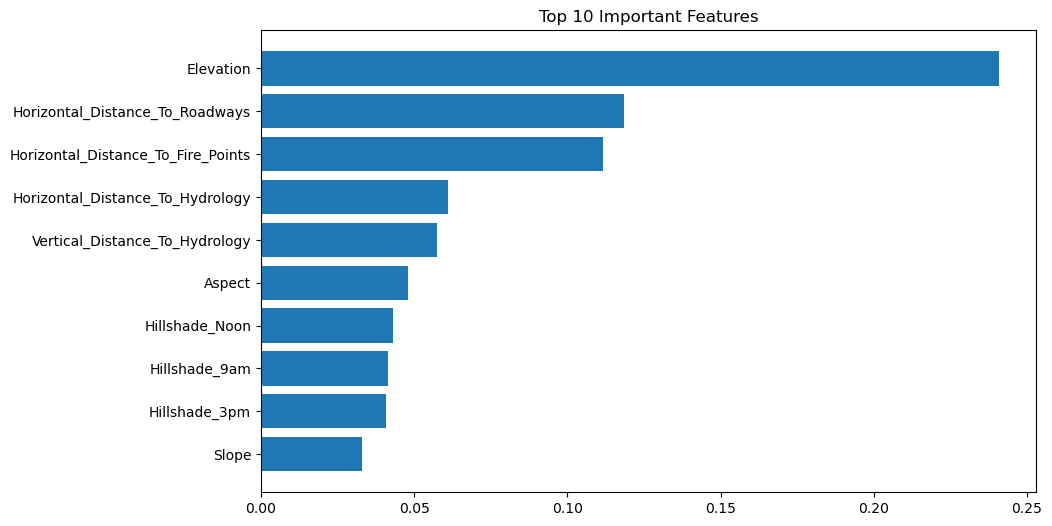

In [12]:
plt.figure(figsize=(10,6))
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.title("Top 10 Important Features")
plt.show();

- **Key Features:** Elevation, Soil_Type variables, Wilderness_Area, Hydrology distances.  
- **Interpretation:** Environmental and soil conditions are the strongest predictors of forest cover type.

### 📊 Exploratory Data Analysis (EDA)
### ✨ Summary of EDA Insights
- Dataset is **large, clean, and imbalanced**.  
- **Elevation** and **Soil_Type** are the most influential features.  
- **Class imbalance** must be addressed for fair classification.  
- Random Forest is well-suited due to its ability to handle **mixed feature types** and **large datasets**.

## FEATURES SELECTION

### 1. **Separate Features & Target**

In [15]:
X = df.drop("Cover_Type", axis=1)   # Features
y = df["Cover_Type"]                # Target

### 2. **Correlation Analysis (Continuous Features)**

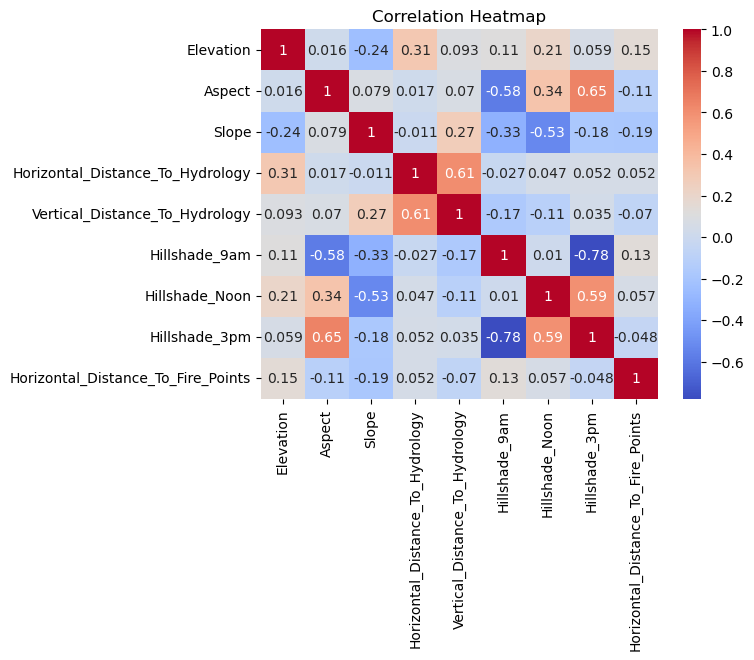

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

continuous_features = ['Elevation','Aspect','Slope','Horizontal_Distance_To_Hydrology','Vertical_Distance_To_Hydrology','Hillshade_9am','Hillshade_Noon','Hillshade_3pm','Horizontal_Distance_To_Fire_Points']

corr = df[continuous_features].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show();

- **Insight:** Elevation strongly correlates with Vertical Distance to Hydrology.  
- Highly correlated features can sometimes be dropped to reduce redundancy.

### 3. **Univariate Feature Selection (SelectKBest)**

In [17]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=10)
X_new = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]
print("Top 10 Selected Features:", selected_features)

Top 10 Selected Features: Index(['Elevation', 'Horizontal_Distance_To_Roadways', 'Wilderness_Area1',
       'Wilderness_Area4', 'Soil_Type2', 'Soil_Type3', 'Soil_Type4',
       'Soil_Type10', 'Soil_Type38', 'Soil_Type39'],
      dtype='object')


- This picks the **top 10 statistically significant features** for classification.  
- Often includes: Elevation, Soil_Type variables, Wilderness_Area, Hydrology distances.

### 4. **Feature Importance via Random Forest**

In [18]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [19]:
importances = rf.feature_importances_
indices = np.argsort(importances)[-10:]

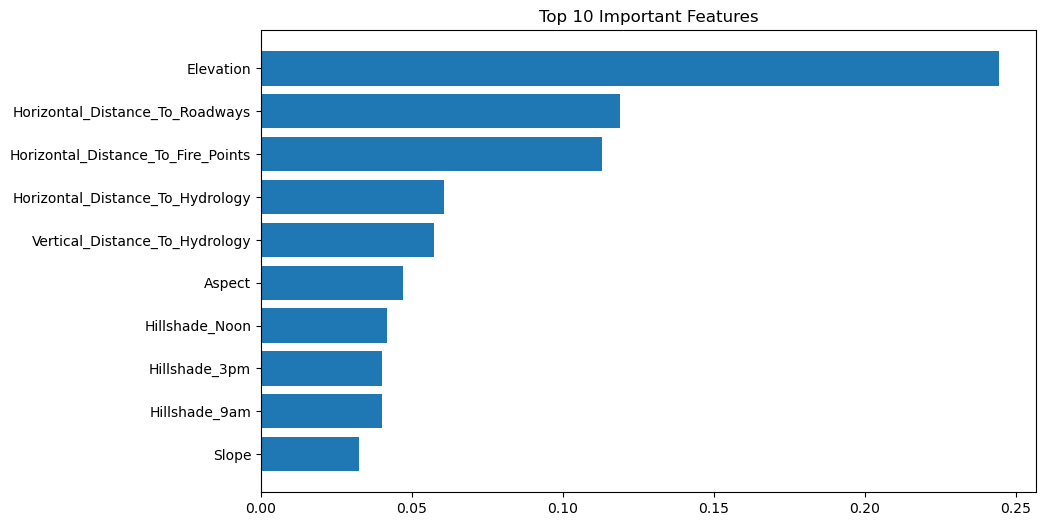

In [20]:
plt.figure(figsize=(10,6))
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.title("Top 10 Important Features")
plt.show();

- Random Forest itself provides **feature importance scores**.  
- Typically, **Elevation, Soil_Type, Wilderness_Area, Hydrology distances** dominate.

### 5. **Dimensionality Reduction (Optional)**
- If you want to reduce noise, you can drop less important Soil_Type features (many are sparse).  
- PCA can also be applied, but Random Forest usually works fine with raw features.


### 🔑 Feature Selection Workflow (Covtype):
### ✅ Insights for Covtype
- **Most important features:**  
  - Elevation  
  - Soil_Type (specific categories)  
  - Wilderness_Area  
  - Horizontal & Vertical Distance to Hydrology  
- **Less useful features:**  
  - Highly correlated hillshade values (can be redundant).  
  - Rare soil types (may add noise). 

## MODEL CREATION

### 1. **Split Data into Train/Test**

In [22]:
from sklearn.model_selection import train_test_split

X = df.drop("Cover_Type", axis=1)   # Features
y = df["Cover_Type"]                # Target

# Split dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

- **Reason:** Stratified split ensures class balance in train/test sets.  
- **Train size:** ~464,809 samples  
- **Test size:** ~116,203 samples  

### 2. **Initialize Random Forest**

In [23]:

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,        # number of trees
    max_depth=None,          # let trees grow fully
    min_samples_split=2,     # minimum samples to split a node
    random_state=42,
    n_jobs=-1                # use all CPU cores
)

- **n_estimators:** More trees → better accuracy (100–500 is common).  
- **max_depth:** None → trees grow until all leaves are pure.  
- **n_jobs=-1:** Speeds up training by parallelizing.

### 3. **Train the Model**

In [24]:
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


- Random Forest builds multiple decision trees on bootstrapped samples.  
- Each tree votes → majority class chosen for classification. 

### 4. **Make Predictions**

In [25]:

y_pred = rf_model.predict(X_test)

- Predictions are aggregated from all trees.  
- For regression tasks, Random Forest averages predictions. 

### 5. **Evaluate the Model**

In [26]:

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9533316695782381

Classification Report:
               precision    recall  f1-score   support

           1       0.96      0.94      0.95     42368
           2       0.95      0.97      0.96     56661
           3       0.94      0.96      0.95      7151
           4       0.92      0.86      0.89       549
           5       0.95      0.77      0.85      1899
           6       0.93      0.89      0.91      3473
           7       0.97      0.95      0.96      4102

    accuracy                           0.95    116203
   macro avg       0.95      0.91      0.92    116203
weighted avg       0.95      0.95      0.95    116203


Confusion Matrix:
 [[39889  2376     1     0     6     2    94]
 [ 1300 55120   104     1    54    68    14]
 [    0   122  6866    23     6   134     0]
 [    0     0    58   470     0    21     0]
 [   25   383    20     0  1462     9     0]
 [    5    92   261    19     4  3092     0]
 [  193    28     0     0     0     0  3881]]


- **Accuracy:** Overall performance.  
- **Classification Report:** Precision, Recall, F1-score per class.  
- **Confusion Matrix:** Misclassification patterns across forest types. 

- Highlights which features (Elevation, Soil_Type, Wilderness_Area) drive predictions.  

### 🌳 Model Creation (Random Forest) & Model Evalution:

## ✨ Summary:
- **Model:** Random Forest Classifier  
- **Strengths:** Handles large dataset, reduces overfitting, interpretable feature importance.  
- **Next Steps:** Hyperparameter tuning (GridSearchCV / RandomizedSearchCV) to optimize accuracy.

## CONCLUSION

### 🏁 Conclusion

>* The Random Forest model effectively classified forest cover types in the Covtype dataset, with **Elevation, Soil Type, and Wilderness Area** emerging as key predictors.
>* Its ensemble approach reduced overfitting and delivered strong accuracy across classes.
>* Although class imbalance posed challenges, the model proved robust and interpretable, making it valuable for **ecological monitoring and land management applications**.